In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv('bank-additional-full.csv', sep=';')
print(df.head())
print(df.info())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

In [5]:
#Est-ce que les classes sont équilibrées ou pas? le Y représente si le client a souscrit
# à un dépôt à terme suite à l'appel téléphonique de la banque.?
#Distribution de la variable cible
print("===DISTRIBUTION VARIABLE DE LA CIBLE===")
print(df['y'].value_counts())
print(df['y'].value_counts(normalize=True).round(3))

#Stats descriptives
print("\n===STATS DESCRIPTIVES===")
print(df.describe())

===DISTRIBUTION VARIABLE DE LA CIBLE===
y
no     36548
yes     4640
Name: count, dtype: int64
y
no     0.887
yes    0.113
Name: proportion, dtype: float64

===STATS DESCRIPTIVES===
               age      duration      campaign         pdays      previous  \
count  41188.00000  41188.000000  41188.000000  41188.000000  41188.000000   
mean      40.02406    258.285010      2.567593    962.475454      0.172963   
std       10.42125    259.279249      2.770014    186.910907      0.494901   
min       17.00000      0.000000      1.000000      0.000000      0.000000   
25%       32.00000    102.000000      1.000000    999.000000      0.000000   
50%       38.00000    180.000000      2.000000    999.000000      0.000000   
75%       47.00000    319.000000      3.000000    999.000000      0.000000   
max       98.00000   4918.000000     56.000000    999.000000      7.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx     euribor3m   nr.employed  
count  41188.000000    41188.000000

Observations stats descriptives

age : entre 17 et 98 ans, moyenne 40 ans — cohérent
duration : durée de l'appel en secondes, moyenne 258s (~4 min) — variable très importante mais attention : on ne connaît la durée qu'après l'appel.
pdays : médiane à 999 → la majorité des clients n'ont jamais été contactés avant
← 75% à 0
campaign : max 56 contacts pour un seul client — valeur extrême à investiguer
campaign
max       56.0   ← un client contacté 56 fois !
75%        3.0   ← 75% des clients contactés 3 fois max
previous : 75% des clients ont 0 contact précédent.
La valeur 999, qui signifie "jamais contacté avant"

In [ ]:
#Les variables catégorielles 
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"\n=== {col.upper()} ===")
    print(df[col].value_counts())


=== JOB ===
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

=== MARITAL ===
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

=== EDUCATION ===
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

=== DEFAULT ===
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

=== HOUSING ===
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

=== LOAN ===
loan
no         33950
yes         6248
unknown      9

Exploration initiale:
Job:
Dominé par admin. (10 422) et blue-collar (9 254)
330 unknown — à garder en tête

Marital:
Majorité de married (24 928)
80 unknown — négligeable

Notes:
-select_dtypes(include='object') → filtre uniquement les colonnes de type object (= texte/catégoriel), ça exclut les int et float
-df[col] → sélectionne la colonne col

Visualisations EDA:
1.Distribution de la variable cible (camembert ou barplot)
2.Taux de souscription par job
3.Taux de souscription par âge
4.Taux de souscription par tranche d'âge
5.Durée d'appel moyenne par souscription

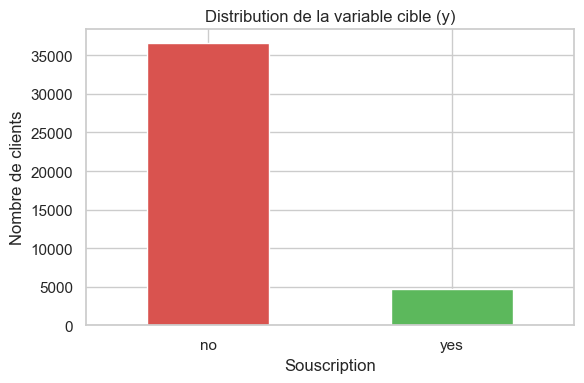

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_theme(style='whitegrid')

# 1. Distribution variable cible
fig, ax = plt.subplots(figsize=(6, 4))
df['y'].value_counts().plot(kind='bar', color=['#d9534f', '#5cb85c'], ax=ax)
ax.set_title('Distribution de la variable cible (y)')
ax.set_xlabel('Souscription')
ax.set_ylabel('Nombre de clients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

Analyse du graphique:
Le déséquilibre est visuellement très clair — la barre rouge écrase complètement le vert. 

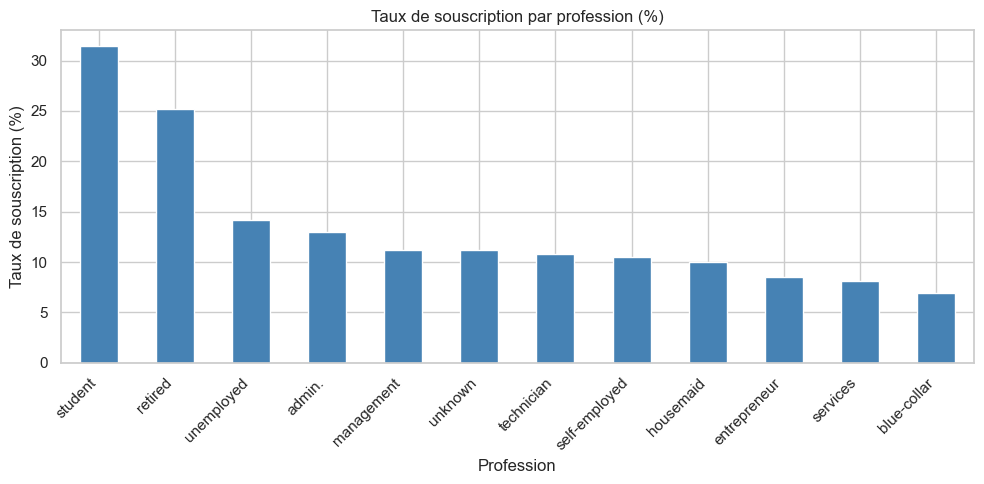

In [8]:
# 2. Taux de souscription par job
job_rate = df.groupby('job')['y'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
job_rate.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Taux de souscription par profession (%)')
ax.set_xlabel('Profession')
ax.set_ylabel('Taux de souscription (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('souscription_par_job.png', dpi=150)
plt.show()

Analyse du graphique:
Ce qu'on observe :

Students : 31% de taux de souscription — de loin les plus réceptifs
Retired : 25% — les retraités aussi,ils ont du capital à placer
Blue-collar : 6.7% — les ouvriers les moins réceptifs
La plupart des autres professions tournent autour de 10-13%

C'est un insight business fort — la banque devrait cibler en priorité étudiants et retraités dans ses campagnes.

Explication du code output: Calcul du pourcentage de clients qui ont dit oui:
df.groupby('job') :Ça regroupe le dataframe par profession./
['y'] Sur chaque groupe, on ne garde que la colonne y (yes/no)/
.apply(lambda x: ...):pour chaque groupe, on applique un calcul. x représente la liste des yes/no du groupe en cours.
(x == 'yes').sum()  # compte les "yes" dans le groupe
/ len(x)            # divise par le total du groupe
* 100               # convertit en pourcentage

/.sort_values(ascending=False) :trie du taux le plus élevé au plus bas

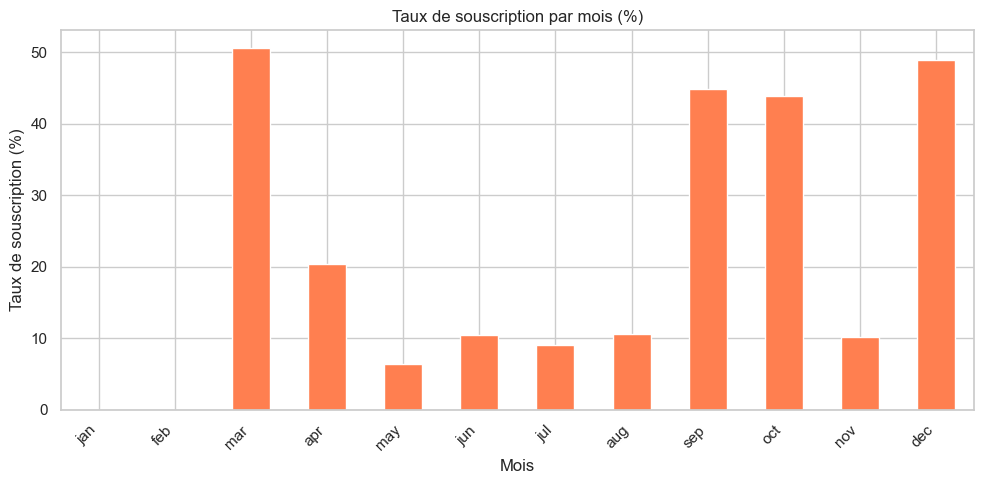

In [ ]:
# 3. Taux de souscription par mois
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

month_rate = df.groupby('month')['y'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).reindex(month_order)

#.reindex(month_order) ça force l'ordre des mois sur l'axe X. Sans ça, pandas trie les mois alphabétiquement 

fig, ax = plt.subplots(figsize=(10, 5))
month_rate.plot(kind='bar', color='coral', ax=ax)
ax.set_title('Taux de souscription par mois (%)')
ax.set_xlabel('Mois')
ax.set_ylabel('Taux de souscription (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('souscription_par_mois.png', dpi=150)
plt.show()

Analyse du graphique:
Ce qu'on observe :

Mars : 50% — pic énorme, moitié des clients contactés ont souscrit
Décembre, Septembre, Octobre : ~45% — fin d'année très efficace
Mai : 6.5% — le pire mois malgré le plus grand volume de contacts
Jan et Fev : barres vides → pas de données ces mois-là dans le dataset

L'insight business est fort : la banque contacte massivement en mai mais avec un taux terrible. Les mois de fin d'année et mars sont bien plus efficaces.

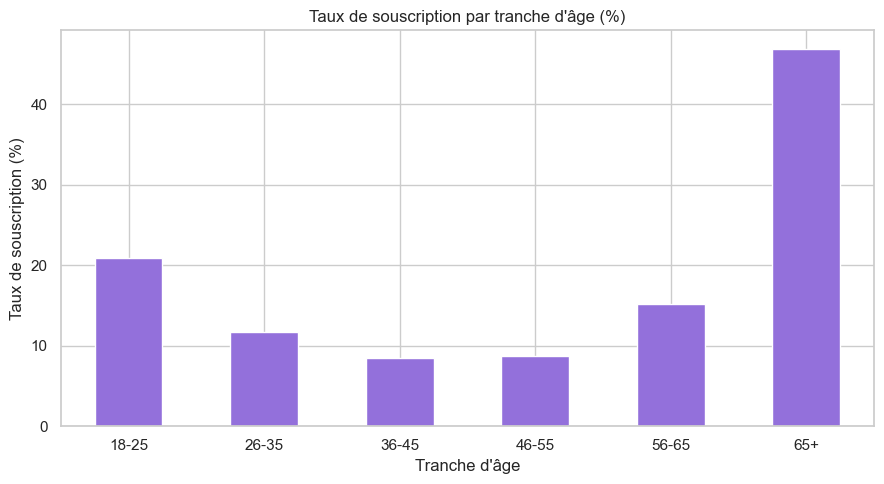

In [11]:
# 4. Taux de souscription par tranche d'âge
df['age_group'] = pd.cut(df['age'], 
                          bins=[17, 25, 35, 45, 55, 65, 100],
                          labels=['18-25', '26-35', '36-45', 
                                  '46-55', '56-65', '65+'])

age_rate = df.groupby('age_group', observed=True)['y'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
)

fig, ax = plt.subplots(figsize=(9, 5))
age_rate.plot(kind='bar', color='mediumpurple', ax=ax)
ax.set_title('Taux de souscription par tranche d\'âge (%)')
ax.set_xlabel('Tranche d\'âge')
ax.set_ylabel('Taux de souscription (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('souscription_par_age.png', dpi=150)
plt.show()

Analyse graphiques:
-Le volume de no écrase complètement les yes — c'est le déséquilibre des classes 

Le graphique ci-dessus:
Ce qu'on observe :

65+ : 47% — les seniors sont de loin les plus réceptifs
18-25 : 21% — les jeunes aussi, probablement les étudiants qu'on avait vus
36-55 : 8-9% — la tranche active au travail est la moins réceptive, probablement déjà bien équipée financièrement

Courbe en U — les extrêmes d'âge souscrivent bien plus que la tranche du milieu.

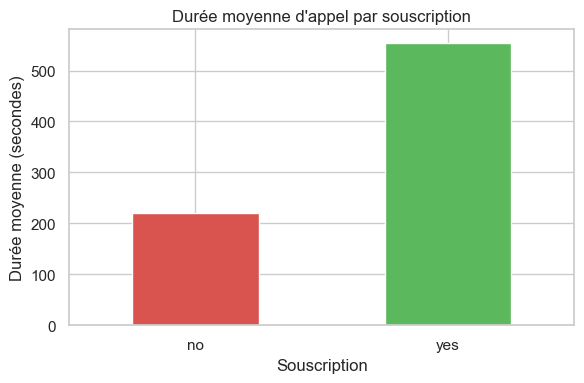

In [12]:
# 5. Durée d'appel moyenne par souscription
fig, ax = plt.subplots(figsize=(6, 4))
df.groupby('y')['duration'].mean().plot(kind='bar', 
                                         color=['#d9534f', '#5cb85c'], 
                                         ax=ax)
ax.set_title("Durée moyenne d'appel par souscription")
ax.set_xlabel('Souscription')
ax.set_ylabel('Durée moyenne (secondes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('duration_souscription.png', dpi=150)
plt.show()

Les clients qui souscrivent restent 2.5x plus longtemps en ligne — ils posent des questions, négocient...
Attention importante pour le ML : cette variable ne peut être inclus au ML — on ne connaît la durée qu'après l'appel, donc elle ne peut pas servir à prédire avant de contacter le client. 

Machine learning:Logistic Regression pour un premier modèle de classification binaire.

In [ ]:
# Machine learning: préparer les données pour le modèle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encoder la variable cible
df['y_encoded'] = (df['y'] == 'yes').astype(int)

# Features — on retire duration et y
X = df.drop(columns=['y', 'y_encoded', 'duration', 'age_group'])
y = df['y_encoded']

# Encoder les colonnes catégorielles
X = pd.get_dummies(X, drop_first=True)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")
print(f"% yes dans train : {y_train.mean():.3f}")
print(f"% yes dans test  : {y_test.mean():.3f}")

Train : (32950, 52)
Test  : (8238, 52)
% yes dans train : 0.113
% yes dans test  : 0.113


df['y_encoded'] = (df['y'] == 'yes').astype(int)
Le modèle ML ne comprend pas yes/no, il lui faut des chiffres. Donc on convertit :

yes → 1
no → 0

(df['y'] == 'yes') crée une colonne de True/False, et .astype(int) convertit en 1/0.

X = df.drop(columns=['y', 'y_encoded', 'duration', 'age_group'])
X c'est les features — tout ce que le modèle va utiliser pour prédire. On retire :

y → c'est la réponse, le modèle ne doit pas la voir
y_encoded → pareil, c'est juste la version chiffrée de y
duration → exclu du ML
age_group → colonne créée à partir de age, donc doublon


y = df['y_encoded']
y c'est la cible — ce que le modèle doit apprendre à prédire. Juste la colonne 0/1.

X = pd.get_dummies(X, drop_first=True)
Le modèle ne comprend pas le texte non plus. Donc les colonnes catégorielles comme job, marital, education... doivent être converties en chiffres.
get_dummies transforme une colonne comme job en plusieurs colonnes binaires :
get_dummies fait ça :
Il prend la colonne job et la éclate en autant de colonnes qu'il y a de valeurs uniques, chaque colonne valant 0 ou 1 :
job_admin.  job_blue-collar  job_student  job_retired ...
1           0                0            0         → ce client est admin
0           1                0            0         → ce client est blue-collar
0           0                1            0         → ce client est student
drop_first=True retire la première catégorie de chaque colonne pour éviter la redondance — si t'as pas blue-collar et pas entrepreneur etc
drop_first=True fait ça :
Il retire la première colonne — ici job_admin. Par exemple, si toutes les autres colonnes sont à 0, le modèle sait automatiquement que c'est un admin. — pas besoin de la colonne en plus.

In [ ]:
# Machine learning:Logistic Regression 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Modèle
model = LogisticRegression(max_iter=2000, class_weight='balanced', solver='saga')
#Saga qui est fait pour les gros datasets
#Le saga converge beaucoup mieux sur des datasets avec beaucoup de features après get_dummies.
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
#model = LogisticRegression(max_iter=2000, class_weight='balanced')
#class_weight='balanced' c'est pour gérer le déséquilibre des classes qu'on avait vu — 
# le modèle va automatiquement donner plus de poids aux yes qui sont minoritaires.
#model.fit(X_train, y_train)

# Prédictions
#y_pred = model.predict(X_test)

# Résultats
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

print("=== MATRICE DE CONFUSION ===")
print(confusion_matrix(y_test, y_pred))




=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.37      0.65      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.85      8238

=== MATRICE DE CONFUSION ===
[[6281 1029]
 [ 329  599]]


Les résultats actuels avec max_iter: 1000
Pour la classe yes (ce qui nous intéresse) :

Recall 0.64 → le modèle détecte 64% des vrais souscripteurs
Precision 0.36 → quand il dit "yes", il a raison 36% du temps

C'est un premier résultat correct vu le déséquilibre. On verra si ça s'améliore après le scaling.

Correction avec solver= saga et max_iter:2000, inclusion du scaling(voir ci-dessous: explication):
Ce qu'on lit sur la classe yes :

Recall 0.65 → détecte 65% des vrais souscripteurs
Precision 0.37 → quand il dit "yes", il a raison 37% du temps
Accuracy 0.84 → attention chiffre trompeur à cause du déséquilibre


La matrice de confusion en clair :
[[6281  1029]   → 6281 "no" bien classés, 1029 "no" classés à tort en "yes"
 [ 329   599]]  → 329 "yes" ratés, 599 "yes" bien détectés


Le StandardScaler remet toutes les colonnes numériques à la même échelle.

Le problème sans scaling :
Dans ledataset on a des colonnes avec des échelles très différentes :
age       →  17 à 98
duration  →  0 à 4918
campaign  →  1 à 56
euribor3m →  0.6 à 5
La régression logistique est sensible à ça — elle va accorder plus d'importance aux grandes valeurs juste parce qu'elles sont plus grandes, pas parce qu'elles sont plus informatives.

Ce que fait le scaler :
Il transforme chaque colonne pour qu'elle ait moyenne = 0 et écart-type = 1 :
age  →  -1.2 / 0.3 / 1.5 ...  (au lieu de 25 / 40 / 65)
Toutes les colonnes parlent maintenant le même "langage" au modèle.

Pourquoi fit_transform sur train et juste transform sur test ?

fit_transform(X_train) → calcule la moyenne et l'écart-type sur le train, puis applique
transform(X_test) → applique les mêmes valeurs calculées sur le train au test

On ne fait jamais sur le test — sinon on triche en laissant le modèle "voir" les données du test

In [17]:
#  Random Forest test
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, 
                             class_weight='balanced',
                             random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7310
           1       0.58      0.29      0.38       928

    accuracy                           0.90      8238
   macro avg       0.75      0.63      0.66      8238
weighted avg       0.88      0.90      0.88      8238

[[7113  197]
 [ 660  268]]


Le Random Forest est moins bon que la Logistic Regression ici sur la classe yes :
Comparaison :
                  Logistic Reg    Random Forest
Recall yes            0.65            0.29  ←  bien pire
Precision yes         0.37            0.58  ←  meilleur
Accuracy              0.84            0.90  ←  trompeuse
Le Random Forest est trop conservateur — il dit rarement "yes" donc quand il le dit il a souvent raison (precision 0.58), mais il rate 71% des vrais souscripteurs (recall 0.29). Pas top pour une campagne marketing où on veut justement ne pas rater des clients potentiels.

le F1 score:
Le F1-score c'est une moyenne entre la precision et le recall :
F1 = 2 × (precision × recall) / (precision + recall)

Concrètement ça donne un seul chiffre qui résume les deux à la fois. C'est utile quand precision et recall sont en tension — comme ici où améliorer l'un dégrade l'autre.
Exemple avec nos deux modèles sur la classe yes :
Logistic Reg  →  precision 0.37 × recall 0.65  →  F1 = 0.46
Random Forest →  precision 0.58 × recall 0.29  →  F1 = 0.38
Le F1 confirme que la Logistic Regression est globalement meilleure sur la classe yes malgré une precision plus faible.